<a href="https://colab.research.google.com/github/Fata-Haidar/244107020108-Pembelajaran-Mesin/blob/main/JS06/JS06_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Langkah 1 - Ilustrasi Data Non-Linier**

In [4]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.9 MB/s eta 0:00:00


**Langkah 1a - Import Library**

In [56]:
	# import library
	import numpy as np
	import matplotlib.pyplot as plt
	from scipy import stats
	import seaborn as sns
	from sklearn.svm import SVC
  from mpl_toolkits import mplot3d
  from sklearn.datasets import make_blobs



**Langkah 1b - Buat Kembali Fungsi Plotting**

In [7]:
	# buat sebuah fungsi untuk menampilkan fitting data

	def plot_svc_decision_function(model, ax=None, plot_support=True):

	    if ax is None:
	        ax = plt.gca()
	    xlim = ax.get_xlim()
	    ylim = ax.get_ylim()

	    # buat grid untuk evaluasi model
	    x = np.linspace(xlim[0], xlim[1], 30)
	    y = np.linspace(ylim[0], ylim[1], 30)
	    Y, X = np.meshgrid(y, x)
	    xy = np.vstack([X.ravel(), Y.ravel()]).T
	    P = model.decision_function(xy).reshape(X.shape)

	    # plot batas dan margin
	    ax.contour(X, Y, P, colors='k',
	               levels=[-1, 0, 1], alpha=0.5,
	               linestyles=['--', '-', '--'])

	    # plot support vectors
	    if plot_support:
	        ax.scatter(model.support_vectors_[:, 0],
	                   model.support_vectors_[:, 1],
	                   s=300, linewidth=1, facecolors='none');
	    ax.set_xlim(xlim)
	    ax.set_ylim(ylim)

**Langkah 1c - Buat Data Dummy Non-Linier**

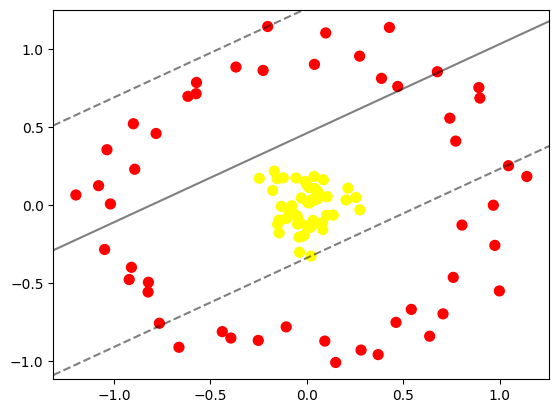

In [164]:
	# contoh data tidak terpisah secara linier
	from sklearn.datasets import make_circles
	X, y = make_circles(100, factor=.1, noise=.1)

	clf = SVC(kernel='linear').fit(X, y)

	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf, plot_support=False);

In [165]:
# Menghitung nilai r
r = np.exp(-(X ** 2).sum(1))

# Membuat grafik 3D
def plot_3D(elev=30, azim=30, X=X, y=y):
    fig = plt.figure(figsize=(8, 6))
    ax = plt.subplot(projection='3d')

    ax.scatter3D(X[:, 0], X[:, 1], r,
                 c=y, s=50, cmap='autumn')

    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

    plt.show()

# Menampilkan grafik interaktif
interact(
    plot_3D,
    elev=[-90, 45, 30, 20, 10],
    azim=(-180, 180),
    X=fixed(X),
    y=fixed(y)
)


interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-8.10022890e-03,  1.52723823e-01],
       [-7.82000063e-01,  4.60340031e-01],
       [ 6.37333366e-01, -8.38719093e-01],
       [-8.92791777e-01,  2.31286440e-01],
       [-1.06870945e-01, -8.46049490e-02],
       [-1.04896042e+00, -2.82853720e-01],
       [ 4.62644771e-01, -7.49944108e-01],
       [-8.99864831e-01,  5.22935752e-01],
       [ 3.59093357e-02,  4.28511520e-02],
       [-2.51814377e-01, -8.65512361e-01],
       [-1.03703162e+00,  3.56447057e-01],
       [-4.85676087e-02, -1.19727203e-01],
       [-2.46751659e-01,  1.73450583e-01],
       [ 4.28550820e-01,  1.14001666e+00],
       [-3.93422705e-02, -1.04553063e-01],
       [-7.89675407e-02, -2.85066643e-03],
       [-2.16051711e-02, -1.97692120e-01],
       [-3.94102569e-01, -8.50383826e-01],
       [-6.63429886e-01, -9.09506953e-01],
       [ 8.04928416e-01, -1.26537090e-01],
       [ 3.87417920e-01,  8.13824919e-01],
       [-1.43538240e-01, -1.76465770e-01],
       [ 9.75449489e-01, -2.56610916e-01],
       [ 2.74857138e-01, -2.87222752e-02],
       [-1.08037069e+00,  1.25976975e-01],
       [ 4.33965055e-02,  1.06337368e-01],
       [ 9.98860910e-01, -5.48438714e-01],
       [ 5.68321164e-02,  4.21926284e-02],
       [ 1.14123034e+00,  1.84918081e-01],
       [ 1.36891385e-01, -6.28224781e-02],
       [ 3.15545265e-02, -9.65807316e-02],
       [-1.06979089e-01, -7.78966610e-01],
       [-2.26811425e-01,  8.64540704e-01],
       [ 4.44028536e-03,  1.71991469e-02],
       [ 2.73965122e-01,  9.56074277e-01],
       [ 4.71568480e-01,  7.61853939e-01],
       [ 5.41987876e-01, -6.66803733e-01],
       [ 2.54490568e-01,  5.04113525e-02],
       [-8.23440335e-01, -5.55337967e-01],
       [-3.83027433e-02, -3.00754290e-01],
       [-8.46623056e-02, -6.09059471e-02],
       [ 7.41846635e-01,  5.58665151e-01],
       [ 1.05393177e-01,  5.54240482e-02],
       [-9.14175693e-02, -4.06102258e-02],
       [ 9.67576245e-01,  7.74310241e-04],
       [ 8.58201835e-02,  1.63744740e-01],
       [-1.19806326e+00,  6.65146676e-02],
       [-8.21830732e-01, -4.92877436e-01],
       [-1.32714610e-01, -6.56113506e-03],
       [-9.09827989e-01, -3.97219663e-01],
       [ 1.07744083e-02,  1.14377540e-01],
       [ 2.05934248e-02, -1.40118159e-01],
       [ 8.24857840e-02, -1.55299722e-01],
       [ 7.59620298e-01, -4.61615222e-01],
       [-1.22378118e-01,  1.75952086e-01],
       [ 5.75648203e-02,  8.71301085e-02],
       [ 1.54626950e-03, -1.32137131e-01],
       [-1.77846801e-01,  9.55096992e-02],
       [ 9.80768707e-02,  1.10468128e+00],
       [-1.35068398e-02, -1.90971096e-01],
       [-6.16839080e-01,  6.98296944e-01],
       [-4.38626311e-01, -8.09343438e-01],
       [ 9.33225992e-02, -8.69847917e-01],
       [ 1.53510962e-02,  1.64315589e-02],
       [ 6.37165900e-02, -1.16672932e-01],
       [-5.72436766e-01,  7.87177578e-01],
       [-5.03095985e-02, -6.76467592e-02],
       [-4.07063091e-02, -2.03537267e-01],
       [-5.74470935e-01,  7.15502130e-01],
       [ 8.92541295e-01,  7.54660919e-01],
       [-3.67706119e-01,  8.86248105e-01],
       [-1.51515510e-01, -1.21251688e-01],
       [ 1.49801003e-01, -1.00696241e+00],
       [-5.64104256e-02,  1.75581791e-01],
       [ 8.97870758e-01,  6.87160855e-01],
       [-2.03127992e-01,  1.14615173e+00],
       [-7.50255851e-02, -4.42373865e-02],
       [ 1.02464731e-01, -6.36985015e-02],
       [ 2.16619424e-02, -3.24906525e-01],
       [ 3.73807316e-02,  1.85289782e-01],
       [ 7.72593251e-01,  4.11654598e-01],
       [-1.54043814e-01,  1.71345075e-01],
       [ 3.69990412e-01, -9.56492439e-01],
       [ 6.77060609e-01,  8.56188991e-01],
       [ 7.06590928e-01, -6.95453739e-01],
       [-7.64885203e-01, -7.55637487e-01],
       [-2.90030143e-02,  4.74273743e-02],
       [ 8.15771311e-02, -1.10496257e-01],
       [-1.45417030e-01, -9.53629815e-02],
       [-6.50207018e-04,  1.33186705e-01],
       [-1.68899510e-01,  2.19310539e-01],
       [ 3.76296661e-02,  3.28400833e-02

**Langkah 2 - Fitting Model**

In [166]:

# Membuat model SVM dengan kernel RBF
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

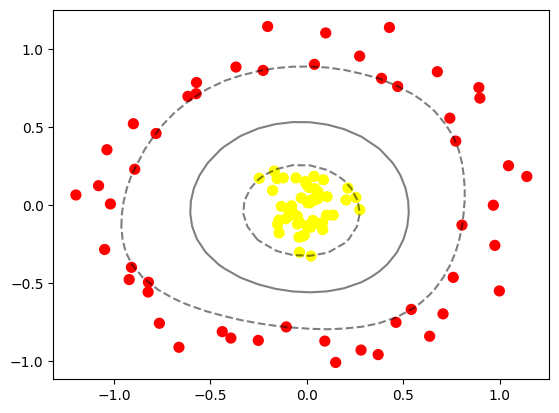

In [167]:
	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf)
	plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
	            s=300, lw=1, facecolors='none')